# MRIxFields2026 — Data Exploration

This notebook walks through:
1. **Data directory structure** — how Training splits are organized
2. **Cross-field comparison** — same subject at 5 field strengths (0.1T → 7T)
3. **Cross-modality comparison** — T1W vs T2W vs T2FLAIR

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# Constants
FIELD_STRENGTHS = ['0.1T', '1.5T', '3T', '5T', '7T']
MODALITIES = ['T1W', 'T2W', 'T2FLAIR']

# Load environment from .env
for line in Path('../.env').read_text().splitlines():
    line = line.strip()
    if line and not line.startswith('#') and '=' in line:
        k, v = line.split('=', 1)
        os.environ.setdefault(k, v)

DATA_DIR = Path(os.environ['DATA_DIR'])
print(f'Data root: .../{DATA_DIR.name}')

Data root: .../release_20260414


## 1. Data Directory Structure

Two training splits:

- **Training_retrospective** — unpaired data (different subjects per scanner), for pretraining
- **Training_prospective** — paired data (same subjects at all 5 field strengths), for fine-tuning

Each split follows: `{split}/{modality}/{field_strength}/*.nii.gz`

In [2]:
for split in ['Training_retrospective', 'Training_prospective']:
    print(f'{split}/')
    split_dir = DATA_DIR / split
    modalities = sorted(d.name for d in split_dir.iterdir() if d.is_dir())
    for i, mod in enumerate(modalities):
        is_last_mod = (i == len(modalities) - 1)
        prefix = '└── ' if is_last_mod else '├── '
        print(f'  {prefix}{mod}/')
        fields = sorted(d.name for d in (split_dir / mod).iterdir() if d.is_dir())
        for j, field in enumerate(fields):
            is_last_field = (j == len(fields) - 1)
            branch = '    ' if is_last_mod else '│   '
            fprefix = '└── ' if is_last_field else '├── '
            print(f'  {branch}{fprefix}{field}/')
    print()

Training_retrospective/
  ├── T1W/
  │   ├── 0.1T/
  │   ├── 1.5T/
  │   ├── 3T/
  │   ├── 5T/
  │   └── 7T/
  ├── T2FLAIR/
  │   ├── 0.1T/
  │   ├── 1.5T/
  │   ├── 3T/
  │   ├── 5T/
  │   └── 7T/
  └── T2W/
      ├── 0.1T/
      ├── 1.5T/
      ├── 3T/
      ├── 5T/
      └── 7T/

Training_prospective/
  ├── T1W/
  │   ├── 0.1T/
  │   ├── 1.5T/
  │   ├── 3T/
  │   ├── 5T/
  │   └── 7T/
  ├── T2FLAIR/
  │   ├── 0.1T/
  │   ├── 1.5T/
  │   ├── 3T/
  │   ├── 5T/
  │   └── 7T/
  └── T2W/
      ├── 0.1T/
      ├── 1.5T/
      ├── 3T/
      ├── 5T/
      └── 7T/



## 2. Cross-Field Comparison

The **prospective** splits contain travelling volunteers scanned at all 5 field strengths.
Below we compare subject 0006 (T1W) across 0.1T → 7T.

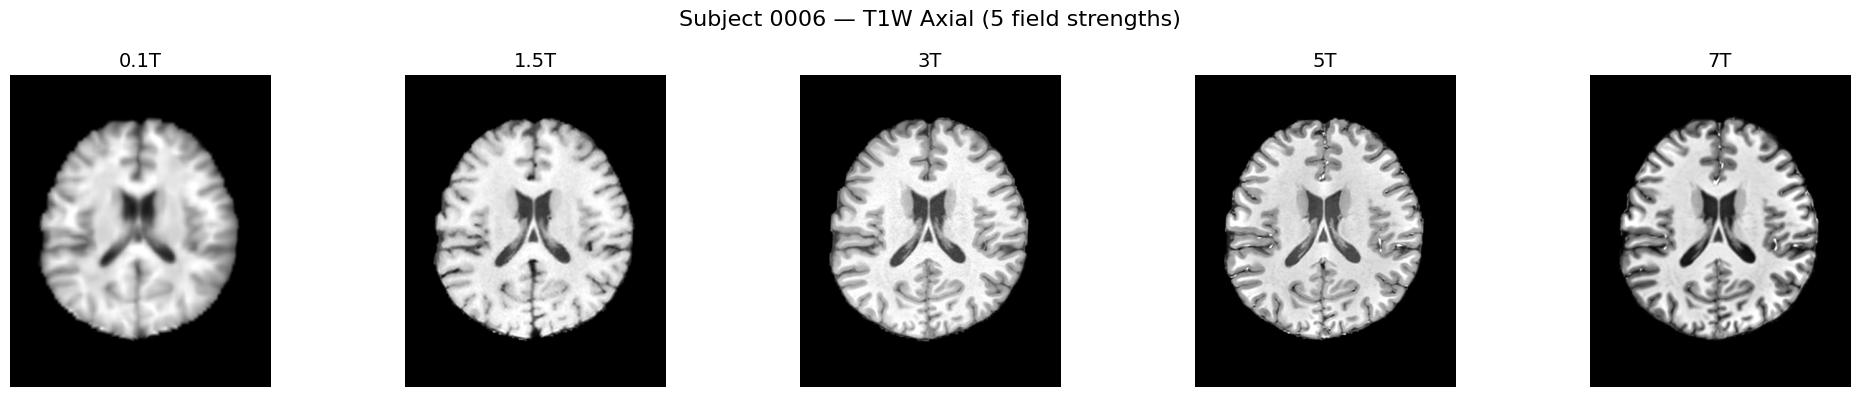

In [3]:
# vmax = 99.5th percentile per slice: suppresses the top 0.5% bright outliers so mid-tone contrast isn't washed out.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, field in enumerate(FIELD_STRENGTHS):
    path = DATA_DIR / 'Training_prospective' / 'T1W' / field / f'P_T1W_{field}_0006.nii.gz'
    vol = nib.load(path).get_fdata()
    mid = vol[:, :, vol.shape[2] // 2]
    axes[i].imshow(mid.T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(mid, 99.5))
    axes[i].set_title(field, fontsize=14)
    axes[i].axis('off')

fig.suptitle('Subject 0006 — T1W Axial (5 field strengths)', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Cross-Modality Comparison

Three modalities: **T1W**, **T2W**, **T2FLAIR** — shown here at 3T.

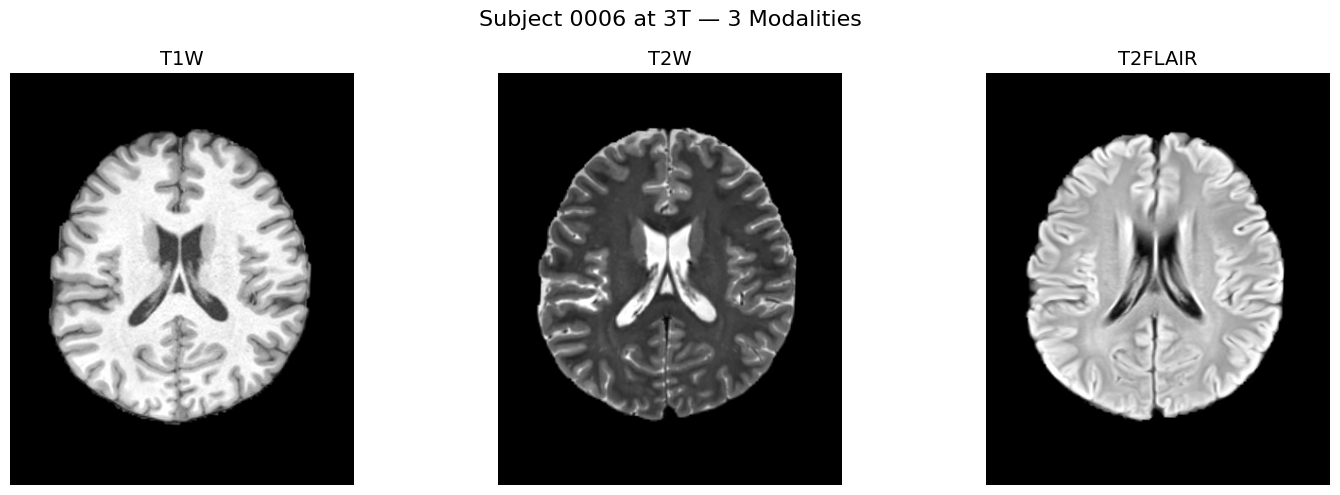

In [4]:
# vmax = 99.5th percentile per slice: suppresses the top 0.5% bright outliers so mid-tone contrast isn't washed out.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, mod in enumerate(MODALITIES):
    path = DATA_DIR / 'Training_prospective' / mod / '3T' / f'P_{mod}_3T_0006.nii.gz'
    vol = nib.load(path).get_fdata()
    mid = vol[:, :, vol.shape[2] // 2]
    axes[i].imshow(mid.T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(mid, 99.5))
    axes[i].set_title(mod, fontsize=14)
    axes[i].axis('off')

fig.suptitle('Subject 0006 at 3T — 3 Modalities', fontsize=16)
plt.tight_layout()
plt.show()

## Summary

- All data: **364×436×364, MNI space**
- 2D axial slices are non-square: **(364, 436)**
- Higher field strength → better SNR, larger intensity range
- **Retrospective** (unpaired) for pretraining, **Prospective** (paired) for fine-tuning & evaluation
- CycleGAN/CUT use native (364, 436) slices; StarGAN v2 pads to (512, 512)

**Next:** See `02_baseline.ipynb` for the preprocessing + training + inference pipeline.